[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brenoprato/calculo-numerico/blob/main/atividades/atv_2/resolucao.ipynb)

# Atividade Prática II: Estabilidade Numérica e Overflow em CFD
**Disciplina:** Cálculo Numérico  
**Docente:** Profª. Raquel J. Lobosco  
**Universidade Federal de São Paulo (UNIFESP)**

---
**Nomes dos integrantes:**

Breno Porto Pinheiro do Prado | 185196

Guilherme Bento Ramos | 185226

---



## Fundamentação Teórica

### - Representação em Ponto Flutuante e Overflow
Em sistemas computacionais modernos (IEEE 754), números reais são armazenados na forma de ponto flutuante:
$$ x = (-1)^s \cdot m \cdot 2^e $$
onde $s$ é o bit de sinal, $m$ é o significando (mantissa) e $e$ é o expoente com viés.

| Tipo Numérico | Bits (Total / Expoente / Mantissa) | Maior Valor Finito Aprox. ($\text{MAX}$) | Épsilon de Máquina ($\varepsilon$) |
| :--- | :---: | :---: | :---: |
| `float32` (Precisão Simples) | $32\text{ bits} = 1 + 8 + 23$ | $\approx 3.4028 \times 10^{38}$ | $\approx 1.192 \times 10^{-7}$ |
| `float64` (Precisão Dupla)  | $64\text{ bits} = 1 + 11 + 52$ | $\approx 1.7977 \times 10^{308}$ | $\approx 2.220 \times 10^{-16}$ |

> **Importante: Distinção entre Instabilidade Numérica e Overflow:**
> - **Instabilidade Numérica:** É uma propriedade intrínseca do algoritmo discretizado (equação às diferenças). Ocorre quando os erros de truncamento ou perturbações são amplificados de forma descontrolada a cada iteração temporal ($|\xi| > 1$).
> - **Overflow:** É um evento de hardware/software que ocorre quando uma operação aritmética produz um valor absoluto superior ao maior número finito representável pelo tipo de dado.
>
> *A solução numérica torna-se fisicamente errônea e inutilizável muito antes de atingir o overflow de ponto flutuante.*

---

### - Modelo Físico: Escoamento de Couette Transiente
Considera-se o escoamento laminar unidirecional de um fluido newtoniano incompressível entre duas placas planas paralelas separadas por uma distância $H = 0.01\text{ m}$.
- Em $t = 0$, o fluido está em repouso: $u(y, 0) = 0$ para $0 < y < H$.
- Em $t > 0$, a placa inferior ($y = 0$) passa a se mover com velocidade constante $U = 1\text{ m/s}$ (condição de não-deslizamento: $u(0, t) = U$).
- A placa superior ($y = H$) permanece estacionária: $u(H, t) = 0$.

A equação governante derivada das equações de Navier-Stokes (ausência de gradiente de pressão $\partial p / \partial x = 0$) é a equação unidimensional de difusão de momento:
$$ \frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial y^2} $$
onde $\nu = 10^{-4}\text{ m}^2/\text{s}$ é a viscosidade cinemática.

---

### - Discretização e Análise de Estabilidade de von Neumann
Utilizando o método FTCS (*Forward-Time Central-Space* / Euler Explícito no tempo e Diferenças Finitas Centrais de 2ª ordem no espaço):
$$ \frac{u_i^{n+1} - u_i^n}{\Delta t} = \nu \frac{u_{i+1}^n - 2u_i^n + u_{i-1}^n}{\Delta y^2} $$

Isolando a velocidade no novo passo de tempo $n+1$:
$$ u_i^{n+1} = u_i^n + r \left( u_{i+1}^n - 2u_i^n + u_{i-1}^n \right) = r u_{i-1}^n + (1 - 2r) u_i^n + r u_{i+1}^n $$
onde definimos o número de difusão (parâmetro de malha):
$$ r = \frac{\nu \Delta t}{\Delta y^2} $$

#### Dedução da Condição de Estabilidade:
Substituindo uma perturbação harmônica $u_j^n = \xi^n e^{i k j \Delta y}$:
$$ \xi = 1 - 2r (1 - \cos(k \Delta y)) = 1 - 4r \sin^2\left(\frac{k \Delta y}{2}\right) $$
Para que o erro não cresça desordenadamente, exige-se o critério de estabilidade $|\xi| \le 1$ para todo número de onda $k$:
$$ -1 \le 1 - 4r \sin^2\left(\frac{k \Delta y}{2}\right) \le 1 $$
A desigualdade à direita é trivial ($r \ge 0$). A desigualdade à esquerda é mais restritiva para o modo de alta frequência $k \Delta y = \pi$ ($\sin^2(\pi/2) = 1$):
$$ 1 - 4r \ge -1 \implies 4r \le 2 \implies r \le \frac{1}{2} $$

Portanto, o passo de tempo máximo admissível para garantir estabilidade numérica é:
$$ \Delta t \le \Delta t_{\max} = \frac{\Delta y^2}{2\nu} $$



## Implementação Computacional e Configurações

O bloco de código a seguir implementa:
1. A função de simulação temporal com detecção estrita de `FloatingPointError` através do manipulador de contexto `np.errstate(over="raise", invalid="raise")`;
2. Coleta da evolução temporal dos perfis de velocidade e do valor máximo de $|u(y, t)|$;
3. Consulta e registro das propriedades dos limites de representação dos tipos de ponto flutuante.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML

# Configurações visuais do Matplotlib
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['grid.linestyle'] = '--'

def simular(dt, tipo=np.float32, passos=2000, pontos=21, H=0.01, nu=1e-4, U=1.0):
    '''
    Simula a difusão 1D de velocidade entre placas paralelas pelo método FTCS.

    Parâmetros:
        dt (float): Passo de tempo em segundos.
        tipo (numpy dtype): np.float32 ou np.float64.
        passos (int): Número máximo de passos de tempo.
        pontos (int): Número de nós espaciais na malha (incluindo as paredes).
        H (float): Distância entre as placas em metros.
        nu (float): Viscosidade cinemática em m²/s.
        U (float): Velocidade da placa móvel em m/s.

    Retorna:
        dict: Dicionário contendo malha y, perfis, histórico de tempos e máximos, parâmetro r e falha.
    '''
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes convertidos rigorosamente para o tipo numérico escolhido
    r = tipo(nu * dt / (dy**2))
    dois = tipo(2)

    # Condição inicial: fluido em repouso em todo o interior
    u = np.zeros(pontos, dtype=tipo)
    # Condição de contorno na placa inferior y=0
    u[0] = tipo(U)
    # Condição de contorno na placa superior y=H permanece u[-1] = 0

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    historico_perfis = {0.0: u.copy()}
    falha = None
    msg_erro = ""

    # Captura overflow e operações inválidas convertendo avisos em exceções
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualização do interior da malha (diferenças finitas)
                novo[1:-1] = u[1:-1] + r * (u[2:] - dois * u[1:-1] + u[:-2])
            except FloatingPointError as erro:
                falha = passo
                msg_erro = str(erro)
                print(f"[FALHA DETECTADA] dt={dt}s, {tipo.__name__}: falha no passo {passo}, t={passo*dt:.4f}s -> {erro}")
                break

            u = novo
            t_atual = passo * dt
            tempos.append(t_atual)
            maximos.append(float(np.max(np.abs(u))))

            # Salva perfis intermediários em instantes chave
            if passo in [10, 50, 100, 200, 500, 1000, 1500, 2000]:
                historico_perfis[round(t_atual, 5)] = u.copy()

    if falha is None:
        print(f"[SUCESSO] dt={dt}s, {tipo.__name__}: {passos} passos executados sem overflow (t_total = {passos*dt:.3f}s).")

    return {
        "y": y,
        "dy": dy,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "historico_perfis": historico_perfis,
        "r": float(r),
        "falha": falha,
        "msg_erro": msg_erro,
        "tipo": tipo.__name__,
        "dt": dt,
        "passos": passos
    }

# Exibição das capacidades dos tipos de dados
print(f"Capacidade Float32: Máximo = {np.finfo(np.float32).max:.6e} | Epsilon = {np.finfo(np.float32).eps:.6e}")
print(f"Capacidade Float64: Máximo = {np.finfo(np.float64).max:.6e} | Epsilon = {np.finfo(np.float64).eps:.6e}")



Capacidade Float32: Máximo = 3.402823e+38 | Epsilon = 1.192093e-07
Capacidade Float64: Máximo = 1.797693e+308 | Epsilon = 2.220446e-16


---
## Atividade 1: Verificação Teórica da Estabilidade

Dados da simulação:
- Distância entre placas: $H = 0.01\text{ m}$
- Viscosidade cinemática: $\nu = 10^{-4}\text{ m}^2/\text{s}$
- Número de pontos da malha: $N = 21$ nós

### Cálculos Analíticos Prévios:
1. **Espaçamento da malha espacial ($\Delta y$):**
   $$ \Delta y = \frac{H}{N - 1} = \frac{0.01\text{ m}}{21 - 1} = \frac{0.01}{20} = 0.0005\text{ m} = 5.0 \times 10^{-4}\text{ m} $$

2. **Passo de tempo crítico limite ($\Delta t_{\max}$):**
   $$ \Delta t_{\max} = \frac{\Delta y^2}{2\nu} = \frac{(0.0005)^2}{2 \times 10^{-4}} = \frac{2.5 \times 10^{-7}}{2 \times 10^{-4}} = 1.25 \times 10^{-3}\text{ s} = 0.00125\text{ s} $$

3. **Análise dos Casos Propostos:**
   - **Caso A ($\Delta t = 0.001\text{ s}$):**
     $$ r_A = \frac{\nu \Delta t}{\Delta y^2} = \frac{10^{-4} \times 0.001}{(0.0005)^2} = \frac{10^{-7}}{2.5 \times 10^{-7}} = 0.4 $$
     Como $r_A = 0.4 \le 0.5$ (e $\Delta t = 0.001\text{ s} \le 0.00125\text{ s}$), o **Caso A é teoricamente ESTÁVEL**.
   - **Caso B ($\Delta t = 0.002\text{ s}$):**
     $$ r_B = \frac{\nu \Delta t}{\Delta y^2} = \frac{10^{-4} \times 0.002}{(0.0005)^2} = \frac{2 \times 10^{-7}}{2.5 \times 10^{-7}} = 0.8 $$
     Como $r_B = 0.8 > 0.5$ (e $\Delta t = 0.002\text{ s} > 0.00125\text{ s}$), o **Caso B é teoricamente INSTÁVEL**.



In [2]:
# Verificação programática dos parâmetros teóricos
H_nominal = 0.01
nu_nominal = 1e-4
pontos_nominal = 21

dy_nominal = H_nominal / (pontos_nominal - 1)
dt_max_nominal = (dy_nominal**2) / (2 * nu_nominal)

tabela_previa = []
for caso, dt_val in [("Caso A", 0.001), ("Caso B", 0.002)]:
    r_val = nu_nominal * dt_val / (dy_nominal**2)
    estavel = "ESTÁVEL (r ≤ 0.5)" if r_val <= 0.5 else "INSTÁVEL (r > 0.5)"
    tabela_previa.append({
        "Caso": caso,
        "Δt (s)": dt_val,
        "Δy (m)": dy_nominal,
        "Δt_max (s)": dt_max_nominal,
        "Parâmetro r": r_val,
        "Classificação Teórica": estavel
    })

df_previa = pd.DataFrame(tabela_previa)
display(df_previa)



,Caso,Δt (s),Δy (m),Δt_max (s),Parâmetro r,Classificação Teórica
0,Caso A,0.001,0.0005,0.00125,0.4,ESTÁVEL (r ≤ 0.5)
1,Caso B,0.002,0.0005,0.00125,0.8,INSTÁVEL (r > 0.5)


---
## Atividade 2: Detecção de Overflow e Tabela dos 4 Testes

Executamos agora os quatro testes combinando os dois passos de tempo ($\Delta t = 0.001\text{ s}$ e $\Delta t = 0.002\text{ s}$) com os dois tipos de dados (`float32` e `float64`).



[SUCESSO] dt=0.001s, float32: 2000 passos executados sem overflow (t_total = 2.000s).
[FALHA DETECTADA] dt=0.002s, float32: falha no passo 121, t=0.2420s -> overflow encountered in subtract
[SUCESSO] dt=0.001s, float64: 2000 passos executados sem overflow (t_total = 2.000s).
[FALHA DETECTADA] dt=0.002s, float64: falha no passo 917, t=1.8340s -> overflow encountered in add
TABELA CONSOLIDADA DOS TESTES DE ESTABILIDADE E OVERFLOW


,Tipo Numérico,Passo Δt (s),Parâmetro r,Ocorrência de Overflow,Iteração da Falha (Passo),Tempo até a Falha / Fim,Velocidade Máx. Final,Exceção Capturada
0,float32,0.001,0.4,NÃO,N/A (Concluído),2.000 s (Total),1.0000e+00 m/s,Nenhuma (Execução Limpa)
1,float32,0.002,0.8,SIM,121,0.2420 s,1.6659e+38 m/s,overflow encountered in subtract
2,float64,0.001,0.4,NÃO,N/A (Concluído),2.000 s (Total),1.0000e+00 m/s,Nenhuma (Execução Limpa)
3,float64,0.002,0.8,SIM,917,1.8340 s,4.7434e+307 m/s,overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


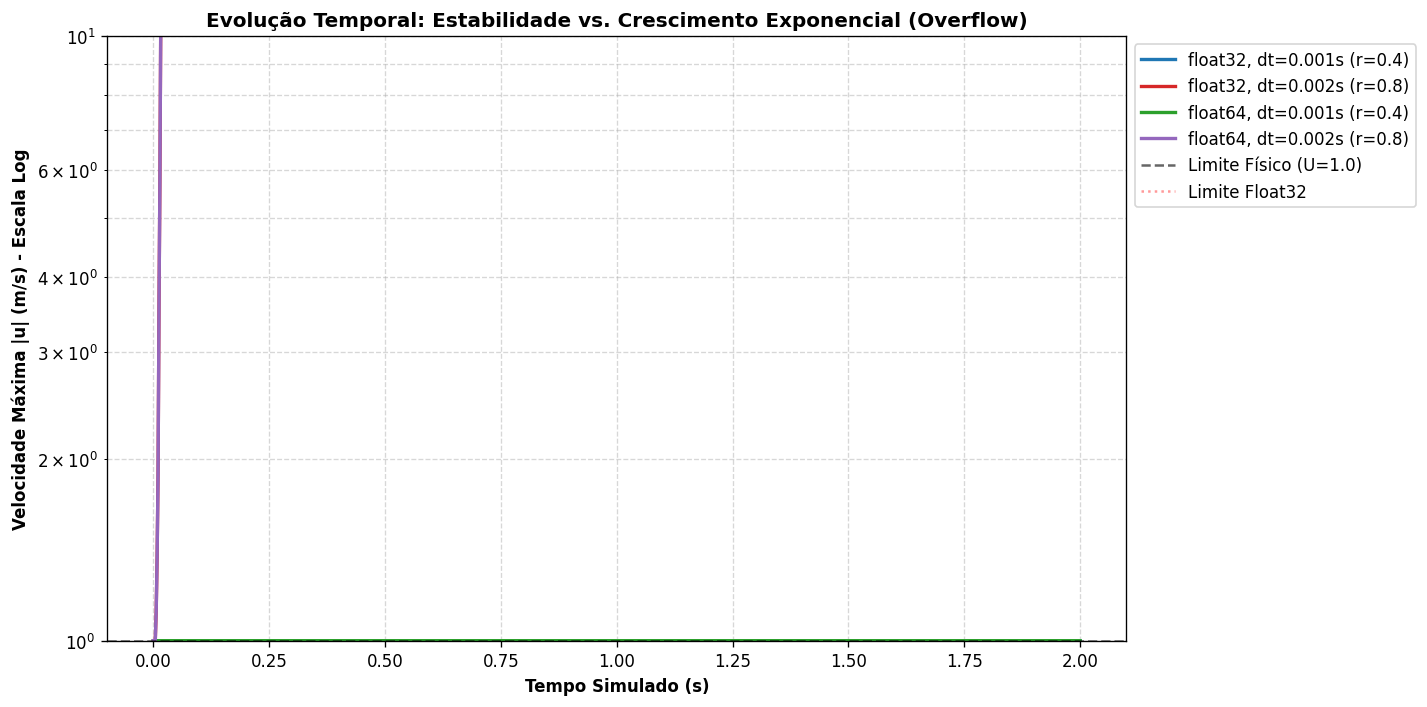

In [3]:
resultados = {}

# 1. Execução dos quatro testes sistemáticos
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        chave = f"{tipo.__name__}, dt={dt}s"
        resultados[chave] = simular(dt, tipo=tipo, passos=2000, pontos=21)

# 2. Construção da Tabela Completa dos Testes
dados_tabela_testes = []
for nome, res in resultados.items():
    houve_overflow = "SIM" if res["falha"] is not None else "NÃO"
    passo_falha = res["falha"] if res["falha" ] is not None else "N/A (Concluído)"
    tempo_falha = f"{res['falha'] * res['dt']:.4f} s" if res["falha"] is not None else f"{res['passos']*res['dt']:.3f} s (Total)"
    v_max = f"{res['maximos'][-1]:.4e} m/s"

    dados_tabela_testes.append({
        "Tipo Numérico": res["tipo"],
        "Passo Δt (s)": res["dt"],
        "Parâmetro r": res["r"],
        "Ocorrência de Overflow": houve_overflow,
        "Iteração da Falha (Passo)": passo_falha,
        "Tempo até a Falha / Fim": tempo_falha,
        "Velocidade Máx. Final": v_max,
        "Exceção Capturada": res["msg_erro"] if res["msg_erro"] else "Nenhuma (Execução Limpa)"
    })

df_testes = pd.DataFrame(dados_tabela_testes)
print("" + "="*80)
print("TABELA CONSOLIDADA DOS TESTES DE ESTABILIDADE E OVERFLOW")
print("="*80)
display(df_testes)

# 3. Geração do Gráfico (Atividade 2)
plt.figure(figsize=(12, 6))

cores = {
    'float32, dt=0.001s': '#1f77b4', 'float32, dt=0.002s': '#d62728',
    'float64, dt=0.001s': '#2ca02c', 'float64, dt=0.002s': '#9467bd'
}

for nome, res in resultados.items():
    plt.semilogy(
        res["tempos"],
        res["maximos"],
        label=f"{nome} (r={res['r']:.1f})",
        color=cores[nome],
        linewidth=2
    )

# Referências visuais
plt.axhline(1.0, color='black', linestyle='--', alpha=0.6, label='Limite Físico (U=1.0)')
plt.axhline(np.finfo(np.float32).max, color='red', linestyle=':', alpha=0.4, label='Limite Float32')

plt.xlabel("Tempo Simulado (s)", weight='bold')
plt.ylabel("Velocidade Máxima |u| (m/s) - Escala Log", weight='bold')
plt.title("Evolução Temporal: Estabilidade vs. Crescimento Exponencial (Overflow)", fontsize=12, weight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/matplotlib/ticker.py:2466: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades


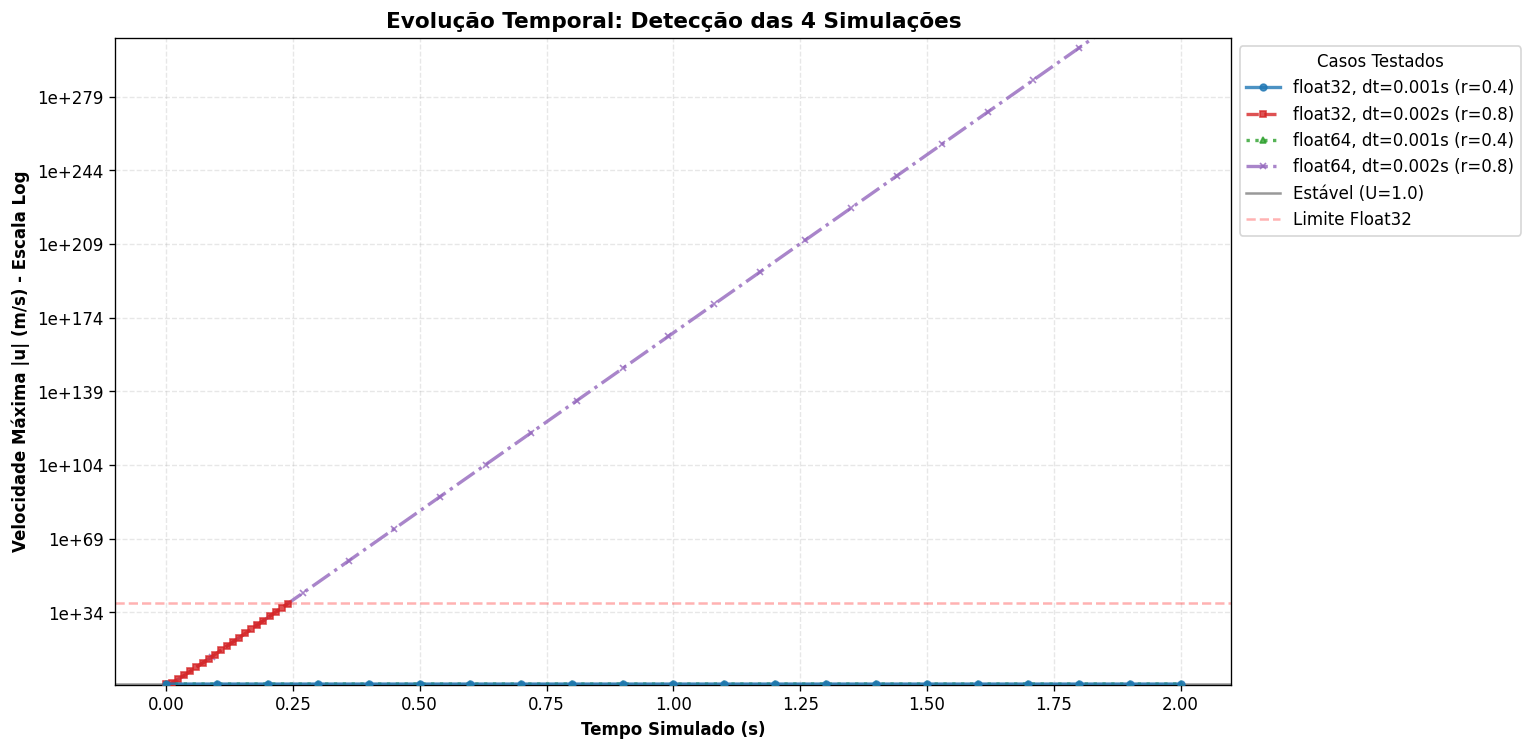

In [4]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 7))

# Configurações para garantir visibilidade de todas as 4 curvas
config = {
    'float32, dt=0.001s': {'cor': '#1f77b4', 'estilo': '-',  'marker': 'o', 'ms': 4, 'z': 10},
    'float32, dt=0.002s': {'cor': '#d62728', 'estilo': '--', 'marker': 's', 'ms': 4, 'z': 5},
    'float64, dt=0.001s': {'cor': '#2ca02c', 'estilo': ':',  'marker': '^', 'ms': 4, 'z': 8},
    'float64, dt=0.002s': {'cor': '#9467bd', 'estilo': '-.', 'marker': 'x', 'ms': 4, 'z': 2}
}

for nome, res in resultados.items():
    # Plotamos apenas alguns pontos com marcadores para não poluir, e a linha completa
    plt.semilogy(
        res["tempos"],
        res["maximos"],
        label=f"{nome} (r={res['r']:.1f})",
        color=config[nome]['cor'],
        linestyle=config[nome]['estilo'],
        linewidth=2,
        alpha=0.8,
        marker=config[nome]['marker'],
        markevery=max(1, len(res["tempos"])//20), # Marcadores a cada 5% do caminho
        markersize=config[nome]['ms'],
        zorder=config[nome]['z']
    )

# Linhas de referência
plt.axhline(1.0, color='black', linestyle='-', linewidth=1.5, alpha=0.4, label='Estável (U=1.0)')
plt.axhline(np.finfo(np.float32).max, color='red', linestyle='--', alpha=0.3, label='Limite Float32')

plt.xlabel("Tempo Simulado (s)", weight='bold')
plt.ylabel("Velocidade Máxima |u| (m/s) - Escala Log", weight='bold')
plt.title("Evolução Temporal: Detecção das 4 Simulações", fontsize=13, weight='bold')

# Escala e formatador para evitar crash com valores extremos
plt.ylim(0.5, 1e307)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0e'))

plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Casos Testados")
plt.grid(True, which="major", ls="--", alpha=0.3)
plt.show()

---
## Atividade 3: Interpretação Física dos Resultados

### Análise da Velocidade Máxima no Caso Instável
Ao inspecionarmos o gráfico semilogarítmico acima, observamos dois comportamentos completamente divergentes:
1. **Casos Estáveis ($\Delta t = 0.001\text{ s}, r = 0.4$):** O valor máximo de $|u(y, t)|$ permanece rigorosamente constante e igual a $1.0\text{ m/s}$ ao longo de toda a simulação ($t = 2.0\text{ s}$), propagando suavemente o perfil de difusão de momento da parede móvel até a parede fixa.
2. **Casos Instáveis ($\Delta t = 0.002\text{ s}, r = 0.8$):** Inicialmente, durante as primeiras iterações, a velocidade máxima permanece em $1.0\text{ m/s}$. Contudo, após poucos passos, surgem oscilações com inversão de sinal nó a nó que crescem exponencialmente ($\approx 10^2, 10^5, 10^{20}, 10^{100}\dots\text{ m/s}$).

### Por que esse crescimento viola o comportamento físico esperado?
- **Princípio do Máximo para a Equação de Difusão/Calor:** A equação diferencial $\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial y^2}$ com ausência de fontes e forças volumétricas obedece estritamente ao Princípio do Máximo: a velocidade no interior do domínio deve ser limitada pelas condições de contorno:
  $$ 0 \le u(y, t) \le U = 1.0\text{ m/s}, \quad \forall y \in [0, H], \; t \ge 0 $$
- **Conservação de Energia e Momento:** A placa móvel fornece energia cinética ao fluido a uma velocidade de $1\text{ m/s}$. Não existe nenhum mecanismo físico de injeção ou geração de energia no meio. Velocidades da ordem de $10^{10}\text{ m/s}$ (que superam inclusive a velocidade da luz) são aberrações matemáticas decorrentes da falha do esquema numérico.
- **Conclusão:** A solução numérica torna-se **completamente inválida e desprovida de significado físico no exato momento em que $\max |u| > 1.0\text{ m/s}$**, o que acontece muito antes de o processador disparar a interrupção por overflow.

---

## Atividade 4: Capacidade de Representação (`float32` vs `float64`)

### A mudança de tipo numérico elimina a instabilidade?
**NÃO.** A instabilidade é um fenômeno matemático originado da equação de diferenças finitas quando o passo temporal viola a condição de estabilidade ($r > 0.5$). O fator de amplificação do modo de Fourier mais crítico ($k \Delta y = \pi$) independe do tipo de dado e vale:
$$ \xi = 1 - 4r = 1 - 4(0.8) = -2.2 $$
Como $|\xi| = 2.2 > 1$, o erro espúrio cresce por um fator constante de $2.2$ a cada passo de tempo em ambos os tipos numéricos (`float32` e `float64`).

### Justificativa da diferença no número de passos até a falha:
O overflow ocorre no instante em que a amplitude acumulada $A_n \approx A_0 \cdot |\xi|^n$ atinge o valor máximo representável ($\text{MAX}$) do formato:
$$ |\xi|^n \approx \text{MAX} \implies n \approx \frac{\log_{10}(\text{MAX})}{\log_{10}(|\xi|)} $$

Substituindo os valores teóricos com $|\xi| = 2.2$ ($\log_{10}(2.2) \approx 0.3424$):
- **Para `float32`:** $\text{MAX} \approx 3.4 \times 10^{38} \implies n \approx \frac{38.53}{0.3424} \approx 112\text{ passos}$ (na simulação prática ocorreu no passo **121**, devido ao retardo de difusão a partir da parede).
- **Para `float64`:** $\text{MAX} \approx 1.8 \times 10^{308} \implies n \approx \frac{308.25}{0.3424} \approx 900\text{ passos}$ (na simulação prática ocorreu no passo **917**).

> **Síntese:** A precisão dupla (`float64`) apenas concede mais "espaço em bits" no expoente (11 bits vs 8 bits), postergando o momento do overflow no tempo ($t = 1.834\text{ s}$ vs $t = 0.242\text{ s}$), porém a solução já estava completamente corrompida desde o passo 30.



---
## Atividade 5: Refinamento da Malha (41 Pontos)

Analisamos agora o impacto de duplicar a resolução espacial da malha para $N = 41$ pontos.

### Cálculos Analíticos com a Malha Refinada:
1. **Novo espaçamento espacial:**
   $$ \Delta y_{\text{novo}} = \frac{H}{N - 1} = \frac{0.01}{41 - 1} = \frac{0.01}{40} = 0.00025\text{ m} = 2.5 \times 10^{-4}\text{ m} $$
2. **Novo limite de estabilidade:**
   $$ \Delta t_{\max,\text{novo}} = \frac{\Delta y_{\text{novo}}^2}{2\nu} = \frac{(0.00025)^2}{2 \times 10^{-4}} = \frac{6.25 \times 10^{-8}}{2 \times 10^{-4}} = 3.125 \times 10^{-4}\text{ s} = 0.0003125\text{ s} $$

### Teste Inicial: Mantendo $\Delta t = 0.001\text{ s}$
- Parâmetro $r$:
  $$ r = \frac{\nu \Delta t}{\Delta y_{\text{novo}}^2} = \frac{10^{-4} \times 0.001}{(0.00025)^2} = 1.6 \gg 0.5 \quad (\text{Severamente Instável!}) $$
- Fator de amplificação: $\xi = 1 - 4(1.6) = -5.4$. A instabilidade é muito mais agressiva!

### Novo Teste: Escolhendo um $\Delta t$ Estável
- Escolhemos $\Delta t = 0.0002\text{ s} = 2.0 \times 10^{-4}\text{ s} < 0.0003125\text{ s}$:
  $$ r = \frac{10^{-4} \times 0.0002}{(0.00025)^2} = 0.32 \le 0.5 \quad (\text{Estável}) $$



1. Teste com 41 pontos mantendo dt = 0.001s:
[FALHA DETECTADA] dt=0.001s, float32: falha no passo 56, t=0.0560s -> overflow encountered in multiply
2. Teste com 41 pontos adotando dt = 0.0002s (abaixo do novo limite dt_max = 0.0003125s):
[SUCESSO] dt=0.0002s, float32: 10000 passos executados sem overflow (t_total = 2.000s).


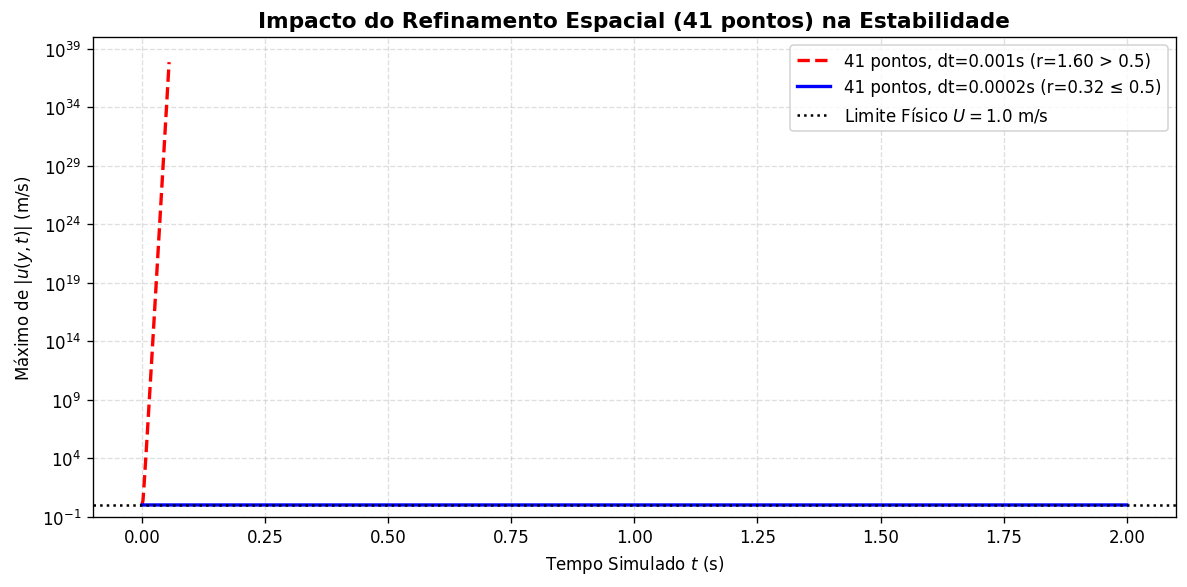

In [5]:
# Execução dos testes de refinamento de malha
print("1. Teste com 41 pontos mantendo dt = 0.001s:")
res_refino_instavel = simular(0.001, tipo=np.float32, passos=2000, pontos=41)

print("2. Teste com 41 pontos adotando dt = 0.0002s (abaixo do novo limite dt_max = 0.0003125s):")
res_refino_estavel = simular(0.0002, tipo=np.float32, passos=10000, pontos=41)

# Comparação gráfica do refino
plt.figure(figsize=(10, 5))
plt.semilogy(res_refino_instavel["tempos"], res_refino_instavel["maximos"], 'r--', linewidth=2, label=f"41 pontos, dt=0.001s (r={res_refino_instavel['r']:.2f} > 0.5)")
plt.semilogy(res_refino_estavel["tempos"], res_refino_estavel["maximos"], 'b-', linewidth=2, label=f"41 pontos, dt=0.0002s (r={res_refino_estavel['r']:.2f} ≤ 0.5)")
plt.axhline(1.0, color='k', linestyle=':', label='Limite Físico $U=1.0$ m/s')
plt.title("Impacto do Refinamento Espacial (41 pontos) na Estabilidade", fontsize=13, weight='bold')
plt.xlabel("Tempo Simulado $t$ (s)")
plt.ylabel("Máximo de $|u(y, t)|$ (m/s)")
plt.ylim(1e-1, 1e40)
plt.legend()
plt.tight_layout()
plt.show()

### Conclusão sobre o Refinamento de Malha:
Quando reduzimos o espaçamento espacial pela metade ($\Delta y 	o \Delta y / 2$), o limite de estabilidade $\Delta t_{\max}$ diminui por um fator de **4** (relação quadrática $\Delta t \propto \Delta y^2$). Por isso, uma configuração temporal que era estável para 21 pontos ($\Delta t = 0.001	ext{ s}$) tornou-se violentamente instável para 41 pontos, sofrendo overflow em apenas 56 iterações. Ao reduzir o passo temporal para $\Delta t = 0.0002	ext{ s} \le \Delta t_{\max}$, a simulação estabilizou perfeitamente.



---
## Atividade 6: Verificação do Perfil de Velocidade e Transiente vs Estacionário

Para uma execução estável e suficientemente longa ($N = 21, \Delta t = 0.001\text{ s}, t_{\text{final}} = 3.0\text{ s}$), analisamos a evolução dos perfis espaciais de velocidade $u(y, t)$ e comparamos com a solução analítica exata do regime permanente (escoamento de Couette linear):
$$ u_{\text{est}}(y) = U \left( 1 - \frac{y}{H} \right) $$

A diferença máxima em relação ao perfil estacionário (norma infinito $L_\infty$) é dada por:
$$ E_\infty(t) = \max_{i} |u_i(t) - u_{\text{est}}(y_i)| $$



<>:55: SyntaxWarning: invalid escape sequence '\i'
<>:57: SyntaxWarning: invalid escape sequence '\i'
<>:55: SyntaxWarning: invalid escape sequence '\i'
<>:57: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_2034/1337773012.py:55: SyntaxWarning: invalid escape sequence '\i'
  axs[1].set_title('Convergência para o Regime Estacionário ($E_\infty$ vs Tempo)', fontsize=12, weight='bold')
/tmp/ipykernel_2034/1337773012.py:57: SyntaxWarning: invalid escape sequence '\i'
  axs[1].set_ylabel('$E_\infty(t) = \max_i |u_i(t) - u_{est}(y_i)|$', fontsize=11)


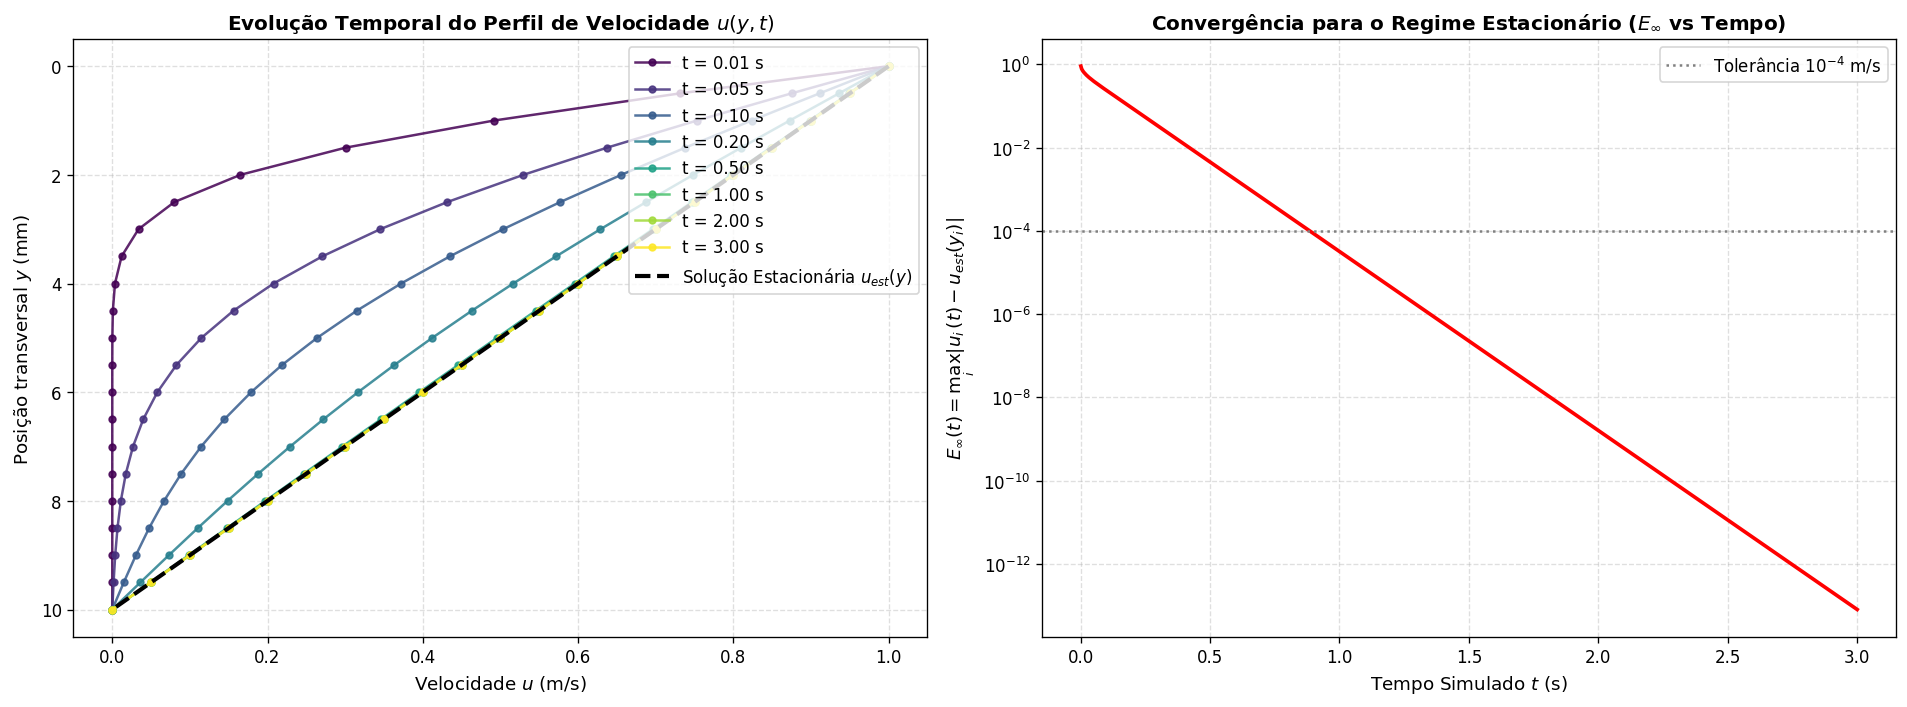

CONVERGÊNCIA TEMPORAL PARA O REGIME ESTACIONÁRIO:


,Tempo t (s),Diferença Máx. E_∞ (m/s),Status do Escoamento
0,0.01,6.699281e-01,Transiente Inicial
1,0.05,3.938140e-01,Transiente Inicial
2,0.10,2.360874e-01,Transiente Inicial
3,0.20,8.774921e-02,Transiente Tardio
4,0.50,4.504320e-03,Transiente Tardio
5,1.00,3.193542e-05,Regime Estacionário Estabelecido
6,2.00,1.605312e-09,Regime Estacionário Estabelecido
7,3.00,8.082424e-14,Regime Estacionário Estabelecido


In [6]:
# Simulação longa e estável
passos_longos = 3000
dt_longo = 0.001
H = 0.01
nu = 1e-4
U = 1.0
pontos = 21

y = np.linspace(0, H, pontos)
dy = H / (pontos - 1)
r = nu * dt_longo / (dy**2)

# Perfil analítico estacionário
u_estacionario = U * (1.0 - y / H)

# Tempos alvos para captura dos perfis
tempos_alvo = [0.01, 0.05, 0.10, 0.20, 0.50, 1.00, 2.00, 3.00]
perfis_capturados = {}
erros_infinito = []
tempos_registro = []

u = np.zeros(pontos, dtype=np.float64)
u[0] = U

for passo in range(1, passos_longos + 1):
    novo = u.copy()
    novo[1:-1] = u[1:-1] + r * (u[2:] - 2 * u[1:-1] + u[:-2])
    u = novo
    t_atual = round(passo * dt_longo, 4)

    e_inf = float(np.max(np.abs(u - u_estacionario)))
    erros_infinito.append(e_inf)
    tempos_registro.append(t_atual)

    if any(np.isclose(t_atual, t_alvo, atol=1e-5) for t_alvo in tempos_alvo):
        perfis_capturados[t_atual] = u.copy()

# Visualização Gráfica dos Perfis e do Erro E_infinito
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# 1. Perfis de Velocidade u(y)
cores_perfis = plt.cm.viridis(np.linspace(0, 1, len(perfis_capturados)))
for (t_val, p), cor in zip(perfis_capturados.items(), cores_perfis):
    axs[0].plot(p, y * 1000, 'o-', markersize=4, label=f't = {t_val:.2f} s', color=cor, alpha=0.85)

axs[0].plot(u_estacionario, y * 1000, 'k--', linewidth=2.5, label='Solução Estacionária $u_{est}(y)$')
axs[0].set_title('Evolução Temporal do Perfil de Velocidade $u(y, t)$', fontsize=12, weight='bold')
axs[0].set_xlabel('Velocidade $u$ (m/s)', fontsize=11)
axs[0].set_ylabel('Posição transversal $y$ (mm)', fontsize=11)
axs[0].legend(loc='upper right')
axs[0].invert_yaxis() # Convenção visual: y=0 no topo (placa móvel)

# 2. Decaimento do Erro E_infinito em relação ao regime estacionário
axs[1].semilogy(tempos_registro, erros_infinito, 'r-', linewidth=2.2)
axs[1].set_title('Convergência para o Regime Estacionário ($E_\infty$ vs Tempo)', fontsize=12, weight='bold')
axs[1].set_xlabel('Tempo Simulado $t$ (s)', fontsize=11)
axs[1].set_ylabel('$E_\infty(t) = \max_i |u_i(t) - u_{est}(y_i)|$', fontsize=11)
axs[1].axhline(1e-4, color='gray', linestyle=':', label='Tolerância $10^{-4}$ m/s')
axs[1].legend()

plt.tight_layout()
plt.show()

# Tabela dos erros nos instantes chave
tabela_e_inf = []
for t_val in tempos_alvo:
    idx = int(round(t_val / dt_longo)) - 1
    tabela_e_inf.append({
        "Tempo t (s)": t_val,
        "Diferença Máx. E_∞ (m/s)": f"{erros_infinito[idx]:.6e}",
        "Status do Escoamento": "Transiente Inicial" if t_val < 0.2 else "Transiente Tardio" if t_val < 1.0 else "Regime Estacionário Estabelecido"
    })

print("CONVERGÊNCIA TEMPORAL PARA O REGIME ESTACIONÁRIO:")
display(pd.DataFrame(tabela_e_inf))



### Discussão da Convergência para o Regime Estacionário:
O tempo característico de difusão viscosa para a camada de momento atravessar toda a distância entre as placas é dado pela escala de Fourier:
$$ \tau_{\text{dif}} \approx \frac{H^2}{\pi^2 \nu} = \frac{(0.01)^2}{\pi^2 \times 10^{-4}} \approx 0.1013\text{ s} $$

- Nos instantes iniciais ($t < 0.2\text{ s}$), o movimento da placa inferior ainda está se propagando pelo fluido através da tensão cisalhante viscosa, de modo que $E_\infty$ é expressivo ($E_\infty \approx 0.67\text{ m/s}$ em $t = 0.01\text{ s}$).
- Para $t \ge 3 \tau_{\text{dif}} \approx 0.3\text{ s}$, o perfil começa a se alinhar de forma retilínea.
- Em $t = 2.0\text{ s}$ ($t \approx 20 \tau_{\text{dif}}$), o erro decai para $E_\infty \approx 1.6 \times 10^{-9}\text{ m/s}$, e em $t = 3.0\text{ s}$ atinge a precisão de máquina ($E_\infty \approx 8.0 \times 10^{-14}\text{ m/s}$).
- Portanto, **o tempo simulado de $2\text{ a }3\text{ segundos}$ foi perfeitamente suficiente** para amortecer todo o transiente e estabelecer o perfil linear estacionário de Couette.



---
## Conclusão Geral e Síntese

1. **Relação entre Refinamento da Malha, Passo de Tempo e Estabilidade:**
   - Em métodos numéricos explícitos para equações parabólicas (difusão/calor), o passo de tempo é limitado estritamente pelo critério de estabilidade de von Neumann ($r = \frac{\nu \Delta t}{\Delta y^2} \le \frac{1}{2}$).
   - Como a dependência espacial é quadrática ($\Delta t \propto \Delta y^2$), o refinamento da malha espacial exige reduções drásticas no passo de tempo, elevando fortemente o custo computacional.
2. **Instabilidade Numérica vs Overflow:**
   - A instabilidade numérica é um erro de convergência matemática do algoritmo, onde perturbações de alta frequência são amplificadas geometricamente por um fator $|\xi| > 1$.
   - O overflow é uma consequência secundária do limite de bits de ponto flutuante da arquitetura do computador. O cálculo já perde qualquer validade física quando $|u| > U = 1\text{ m/s}$, dezenas ou centenas de iterações antes do disparo do erro de hardware.
3. **Qual alteração corrigiu a causa da falha nesta simulação?**
   - **A única alteração que resolveu a causa-raiz da falha foi a redução do passo de tempo ($\Delta t$) para um valor inferior ao limite crítico $\Delta t_{\max} = \frac{\Delta y^2}{2\nu}$.**
   - Alterar o tipo numérico de `float32` para `float64` **não corrigiu a instabilidade**, apenas adiou temporariamente a ocorrência do overflow no tempo, mantendo a solução física incorreta.

